# **I. Evaluation de la standardisation des images** :
### Sont-elles de la même taille ?

In [1]:
# APPEL DE SUPPRESSION DES DATA IMAGES ET SONS, N'EXECUTER QUE SI VOUS SAVEZ CE QUE VOUS FAITES
#delete_all_data()
# TEST LIGHTNING STUDIO

NameError: name 'delete_all_data' is not defined

In [1]:
print("Installation des bibliothèques en cours..")
!pip install torchinfo -q
!pip install plotly -q
!pip install librosa -q
!pip install seaborn -q
!pip uninstall mlflow -y
!pip uninstall protobuf pandas requests -y -q
!pip install "mlflow[extras]==3.5.0" --no-cache-dir -q
!pip install protobuf pandas<3.0.0 requests -q
print("..fait. Redémarrez votre environnement.")

Installation des bibliothèques en cours..


zsh:1: no such file or directory: 3.0.0
..fait. Redémarrez votre environnement.


In [2]:
!pip install torchviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchviz]


In [2]:
# Importation des packages
import torch
from torchinfo import summary
import torchvision.transforms.v2 as transforms
from torchvision import datasets
from PIL import Image
import requests
from io import BytesIO

import plotly.graph_objects as go
import os, shutil
import pandas as pd
import plotly.express as px
import numpy as np
import torch.nn as nn
import torch.optim as optim
import librosa
import seaborn
import boto3
from dotenv import load_dotenv
import mlflow
import mlflow.pytorch
from sklearn.metrics import ConfusionMatrixDisplay, f1_score
import datetime
import matplotlib
import matplotlib.pyplot as plt
from torchviz import make_dot
from mlflow.models.signature import ModelSignature, infer_signature
from mlflow.types import Schema, TensorSpec
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
# J4AIME LES TESTS


In [3]:
# Initialisation et création des répertoires s'ils n'existent pas
# Local de base
path_base = "gtzan-dataset-music-genre-classification"
path_data = path_base + "/Data"
# Local des images RGB de spectrogrammes entiers
path_image = path_base + "/Data/images_original"
# Local des sons à partir desquels les spectrogrammes seront/ont été générés
path_sound = path_base + "/Data/genres_original"
# Local des images grey des spectrogrammes harmoniques
path_harmo = path_base + "/Data/img_harmo"
# Local des images grey des spectrogrammes percussifs
path_percu = path_base + "/Data/img_percu"
# Le dataset nous facilitant les modules d'entrainements
path_ds = path_base + "/Data/features_30_sec.csv"
path_ds_split = path_base + "/Data/features_3_sec.csv"
# Chargement des variables d'environnement
# acces S3, cles , mlflowserver , neondb, artifactroot
load_dotenv()

True

In [3]:
get_from_s3()

NameError: name 'get_from_s3' is not defined

In [4]:
generate_spectrogrammes()

NameError: name 'generate_spectrogrammes' is not defined

In [13]:
os.mkdir(path_base)

In [14]:
os.mkdir(path_data)

In [12]:
# FONCTION DE SUPPRESSION DES ESPACES DATA ET SON LOCAL
def delete_all_data():
    # Suppression du domaine de data LOCAL
    if os.path.exists(path_base):
        shutil.rmtree(path_base)

# Fonction de récupération des données sur le S3
def get_from_s3():

    try:
        print("Initialisation du client..")
        prefix = "music-database/"
        s3 = boto3.resource("s3")
        bucket = s3.Bucket(os.getenv("DATA_S3")) 
        print("..fait.")

        print("[Récupération des données depuis {}]".format(os.getenv("DATA_S3")))

        # Dataset 30sec
        print("Téléchargement du dataset en cours..")
        bucket.download_file(prefix + path_ds, path_ds)
        print("..fait.")

        # Sons wav
        print("Téléchargement des sons en cours..")
        l_sounds = [str(k.key) for k in bucket.objects.filter(Prefix = prefix + path_sound)]


        for s3_key in l_sounds:
            print("\r Progression : {:.2f}% | {}.       ".format((l_sounds.index(s3_key)/len(l_sounds))*100, s3_key), end="", flush=True)
            path_out = os.path.dirname(s3_key).replace(prefix, "")
            file_out = s3_key.replace(prefix, "")
            os.makedirs(path_out, exist_ok = True)
            bucket.download_file(s3_key, file_out)
        print("\r..fait.                            \n", flush = True)
        print("[Données récupérées]")
        
    except Exception as e:
        print("Erreur lors du téléchargement : {}.".format(e))
        delete_all_data()

# Importation du dataset music/spectrogram/features (DEPRECATED, PASSAGE PAR S3)
"""zip_file = "gtzan-dataset-music-genre-classification.zip"
ext_file = "gtzan-dataset-music-genre-classification"

if os.path.exists(ext_file):
  print("Folder already exist, no downloading.")
else:
  print("Downloading {}..".format(zip_file))
  !curl -L -o "./gtzan-dataset-music-genre-classification.zip" "https://www.kaggle.com/api/v1/datasets/download/andradaolteanu/gtzan-dataset-music-genre-classification"
  print("..done.", "\n")
  print("Extracting {}..".format(zip_file))
  !unzip -o -q gtzan-dataset-music-genre-classification.zip -d gtzan-dataset-music-genre-classification
  print("..done.", "\n")
  print("Deleting {}..".format(zip_file))
  !rm -rf gtzan-dataset-music-genre-classification.zip
  print("..done.", "\n")"""

'zip_file = "gtzan-dataset-music-genre-classification.zip"\next_file = "gtzan-dataset-music-genre-classification"\n\nif os.path.exists(ext_file):\n  print("Folder already exist, no downloading.")\nelse:\n  print("Downloading {}..".format(zip_file))\n  !curl -L -o "./gtzan-dataset-music-genre-classification.zip" "https://www.kaggle.com/api/v1/datasets/download/andradaolteanu/gtzan-dataset-music-genre-classification"\n  print("..done.", "\n")\n  print("Extracting {}..".format(zip_file))\n  !unzip -o -q gtzan-dataset-music-genre-classification.zip -d gtzan-dataset-music-genre-classification\n  print("..done.", "\n")\n  print("Deleting {}..".format(zip_file))\n  !rm -rf gtzan-dataset-music-genre-classification.zip\n  print("..done.", "\n")'

Récupération des données sur le S3 du projet avec création totale de l'arborescence nécessaire.

In [9]:
# Fonction de création des répertoires locaux de data
def rep_cnn_audio():

    if not os.path.exists(path_base):

        # Création du répertoire local
        os.makedirs(path_base)
        os.makedirs(path_data)
        # Récupération depuis le s3
        get_from_s3()
        


In [14]:
# Spectrogrammes généraux
os.makedirs(path_image)
# Harmoniques
os.makedirs(path_harmo)
# Percussifs
os.makedirs(path_percu)
# SOus-répertoires des spectrogrammes par genre
for d in os.listdir(path_sound):
    os.makedirs(path_image + "/" + d)
    os.makedirs(path_harmo + "/" + d)
    os.makedirs(path_percu + "/" + d)




FileExistsError: [Errno 17] File exists: 'gtzan-dataset-music-genre-classification/Data/img_harmo'

In [8]:
def mel_hpss(in_path:str, out_path_b:str, out_path_h:str, out_path_p:str):

    y, sr = librosa.load(in_path)
    y, _ = librosa.effects.trim(y)

    n_fft = 2048        # Précision des détails du timbre
    hop_length = 512    # Résolution temporelle
    n_mels = 128        # Hauteur de la fréquence

    # Séparation harmonique/percussive
    y_full = y
    y_harmonic, y_percussive = librosa.effects.hpss(y)

    #S_base = librosa.feature.melspectrogram(y=y_full, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels = n_mels)
    S_h = librosa.feature.melspectrogram(y=y_harmonic, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels = n_mels)
    S_p = librosa.feature.melspectrogram(y=y_percussive, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels = n_mels)

    #S_DB = librosa.power_to_db(S_base, ref=np.max) # nous avons remplacé amplitude_to_db
    S_DB_h = librosa.power_to_db(S_h, ref=np.max)
    S_DB_p = librosa.power_to_db(S_p, ref=np.max)

    #S_DB = np.flipud(S_DB)
    S_DB_h = np.flipud(S_DB_h)
    S_DB_p = np.flipud(S_DB_p)

    #norm_S_DB = (S_DB - S_DB.min()) / (S_DB.max() - S_DB.min())
    norm_S_DB_h = (S_DB_h - S_DB_h.min()) / (S_DB_h.max() - S_DB_h.min())
    norm_S_DB_p = (S_DB_p - S_DB_p.min()) / (S_DB_p.max() - S_DB_p.min())

    #img_f = Image.fromarray((norm_S_DB * 255).astype(np.uint8))
    img_h = Image.fromarray((norm_S_DB_h * 255).astype(np.uint8), mode = "L")
    img_p = Image.fromarray((norm_S_DB_p * 255).astype(np.uint8), mode = "L")

    #img_f = img_f.resize((512, 256), Image.Resampling.LANCZOS)
    img_h = img_h.resize((256, 128), Image.Resampling.LANCZOS)
    img_p = img_p.resize((256, 128), Image.Resampling.LANCZOS)

    #img_f.save(out_path_b)
    img_h.save(out_path_h)
    img_p.save(out_path_p)

# Fonction de formatage et de sauvegarde des spectrogrammes
def array_to_custom_image(db_array, path, cmap_name='inferno'):
    # Inversion verticale pour avoir les basses fréquences en bas [History]
    db_array = np.flipud(db_array)

    # Normalisation entre 0 et 1 pour l'affichage
    norm_db = (db_array - db_array.min()) / (db_array.max() - db_array.min() + 1e-10)
    
    if cmap_name == 'L':
        # Conversion directe en mode L (Luminance / Gray)
        img = Image.fromarray((norm_db * 255).astype(np.uint8), mode = "L")
        #img = Image.fromarray((norm_db * 255).astype(np.uint8), mode='L')
    else:
        # Application de la palette couleur (ex: inferno pour du RGB)
        color_map = matplotlib.colormaps[cmap_name]
        colored_data = color_map(norm_db)[:, :, :3]
        # On ne garde que les 3 premiers canaux (RGB) et on convertit en 8-bit
        img = Image.fromarray((colored_data * 255).astype(np.uint8), mode = "RGB")
        #img = Image.fromarray((colored_data[:, :, :3] * 255).astype(np.uint8))
    
    # Redimensionnement final pour ton CNN (256 de large x 128 de haut) [History]
    img = img.resize((256, 128), Image.Resampling.LANCZOS)
    img.save(path)


def save_clean_plot(S_DB, sr, hop_length, s_color, out_path):
    plt.figure(figsize = (16, 6))
    # y_axis='log' est crucial pour correspondre à l'audition humaine [2, 7]
    librosa.display.specshow(S_DB, sr=sr, hop_length=hop_length, y_axis = 'log', cmap = s_color)

    plt.axis("off")
    plt.margins(0)
    plt.gca().set_axis_off()

    plt.savefig(out_path, 
            bbox_inches='tight', # Supprime les bordures blanches [6]
            pad_inches=0,        
            transparent=True)
    plt.close()

# Génération itérative des trois spectrogrammes #######
def generate_spectrogrammes():

    print("Génération des images de spectrogramme..")
    l_task = len(ds["filename"])

    for i, (fn, path_in, path_out_b, path_out_h, path_out_p) in enumerate(
        zip(ds["filename_wav"], ds["path_wav"], ds["path"], ds["path_harmo"], ds["path_percu"])
    ):
        print("\rProgression : {:.2f}% | {}               ".format(100*(i/l_task), fn), end = "", flush = True)
        
        mel_hpss(path_in, path_out_b, path_out_h, path_out_p)

    print("\r..fait                                                                   ", flush = True)


########

def load_features():
    file_path = path_ds
    
    features_df = pd.read_csv(file_path)
    return features_df
    


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [5]:
ds.head()

NameError: name 'ds' is not defined

In [25]:
# appel de la boucle generant les spectrog et sauve 
generate_spectrogrammes()

Génération des images de spectrogramme..
..fait                                                                   


##### Travaux sur le dataset

Nous effectons du nettoyage sur le dataset.

In [ ]:
def delete_imgs():

    shutil.rmtree(path_image)
    shutil.rmtree(path_harmo)
    shutil.rmtree(path_percu)

    # Spectrogrammes généraux
    os.makedirs(path_image)
    # Harmoniques
    os.makedirs(path_harmo)
    # Percussifs
    os.makedirs(path_percu)
    # SOus-répertoires des spectrogrammes par genre
    for d in os.listdir(path_sound):
        os.makedirs(path_image + "/" + d)
        os.makedirs(path_harmo + "/" + d)
        os.makedirs(path_percu + "/" + d)

#delete_imgs()


In [20]:
generate_spectrogrammes()

Génération des images de spectrogramme..
Progression : 0.00% | blues.00000.wav               

FileNotFoundError: [Errno 2] No such file or directory: 'gtzan-dataset-music-genre-classification/Data/img_harmo/blues/blues00000.png'

In [10]:
# Exécution de la création si non existant : création des répertoires, sous-répertoires, récupération des fichier audio et génération des spectrogrammes
rep_cnn_audio()

# Préparation du dataset, en ignorant jazz.00054.wav (corrompu)

ds = pd.read_csv(path_ds, encoding = "utf-8")
ds = ds[ds["filename"] != "jazz.00054.wav"]
ds = ds.sort_values(by = "label", ascending = True)

c_to_drop = [c for c in ds.columns if c not in ["filename", "label"]]
ds = ds.drop(columns = c_to_drop)

ds["filename_wav"] = ds["filename"]
ds["filename"] = [str.replace(c, ".wav", ".png").replace(".0", "0") for c in ds["filename"]]
ds["path_harmo"] = [path_harmo + "/" + c + "/" + f for c, f in zip(ds["label"], ds["filename"])]
ds["path_percu"] = [path_percu + "/" + c + "/" + f for c, f in zip(ds["label"], ds["filename"])]
ds["path"] = [path_image + "/" + c + "/" + f for c, f in zip(ds["label"], ds["filename"])]
ds["path_wav"] = [path_sound + "/" + c + "/" + f for c, f in zip(ds["label"], ds["filename_wav"])]
ds.head()

# Génération des spectrogrammes
if not os.path.exists(path_base):
    generate_spectrogrammes()

In [11]:
# build table ds2 with features + images location:
features_df = load_features()
display(features_df.head())

ds2 = ds.merge(features_df, how='left', left_on='filename_wav', right_on='filename')
ds2 = ds2.drop(columns=['filename_y',"length","label_y"])
ds2 = ds2.rename(columns={'filename_x': 'filename'})
ds2 = ds2.rename(columns = {'label_x':'label'})
# features in cols 7 to 64 incl
ds2.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


,filename,label,filename_wav,path_harmo,path_percu,path,path_wav,chroma_stft_mean,chroma_stft_var,rms_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,blues00000.png,blues,blues.00000.wav,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,0.350088,0.088757,0.130228,...,0.752740,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035
1,blues00072.png,blues,blues.00072.wav,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,0.306966,0.080736,0.103912,...,10.866509,50.957409,-12.646425,33.409187,2.814977,33.109283,-13.340693,34.954128,-4.368555,44.192883
2,blues00071.png,blues,blues.00071.wav,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,0.305175,0.080065,0.120560,...,6.537729,39.875996,-10.848482,36.344803,3.321702,41.157864,-6.186610,42.471439,3.005219,40.276005
3,blues00070.png,blues,blues.00070.wav,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,0.322809,0.091978,0.106137,...,1.961996,70.742172,-12.309114,93.009857,3.256355,64.567757,-8.804638,64.459396,-3.371866,71.511757
4,blues00069.png,blues,blues.00069.wav,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,0.292001,0.086788,0.116523,...,-4.928004,60.066441,-10.414240,59.111187,-2.043781,115.391167,-1.762690,104.849838,-3.962453,77.253914


Décomposition des propriétés harmoniques et percussives des spectrogrammes : 


FileNotFoundError: [Errno 2] No such file or directory: 'gtzan-dataset-music-genre-classification/Data/images_original/classical/classical00085.png'

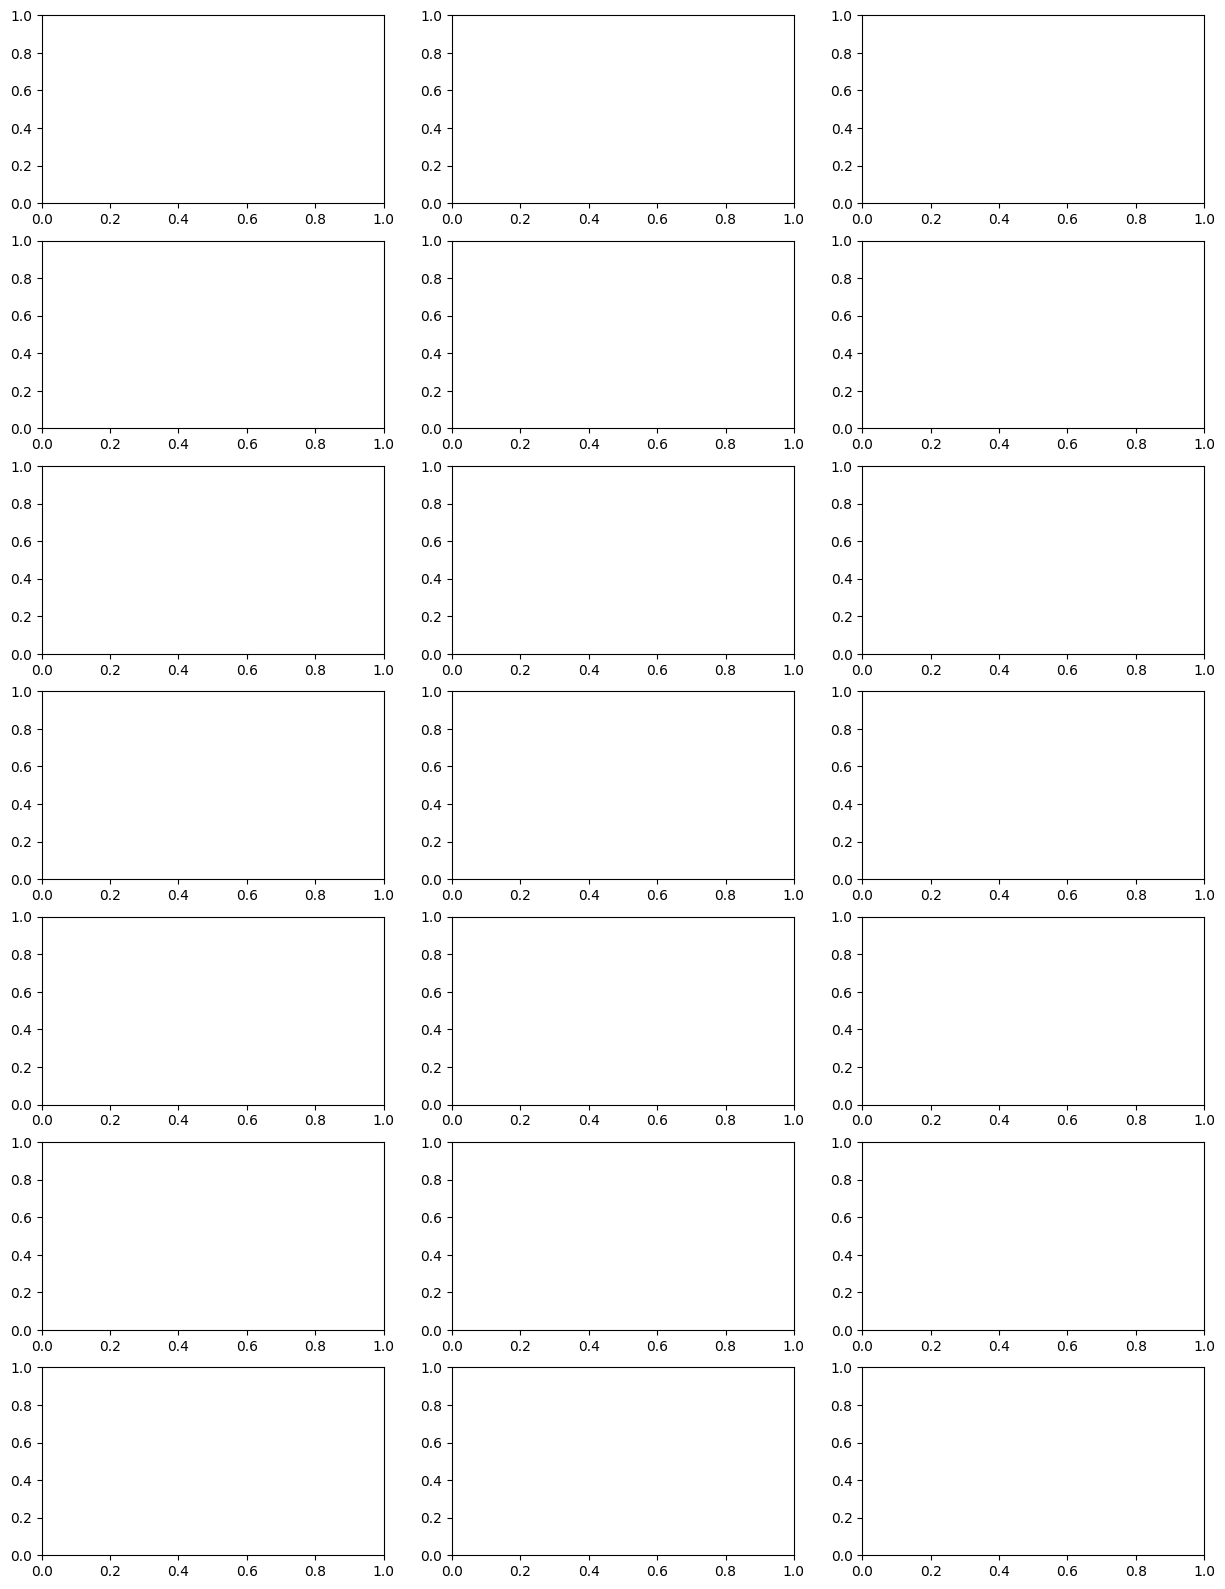

In [12]:

# Sample 12 random images
occurrences = ds.sample(7)

# Create a figure and a grid of subplots
fig, axes = plt.subplots(7, 3, figsize=(15, 20))
#axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

print("Décomposition des propriétés harmoniques et percussives des spectrogrammes : ")

for i, (index, occurence) in enumerate(occurrences.iterrows()):
    image = Image.open(occurence["path"])
    axes[i,0].imshow(image)
    axes[i,0].set_title(occurence["label"] + " : " + occurence["filename"])
    axes[i,0].axis("off")  # Hide axes

    image = Image.open(occurence["path_harmo"])
    axes[i,1].imshow(image, cmap = "gray")
    axes[i,1].set_title(occurence["label"] + " harmo : " + occurence["filename"])
    axes[i,1].axis("off")  # Hide axes

    image = Image.open(occurence["path_percu"])
    axes[i,2].imshow(image, cmap = "gray")
    axes[i,2].set_title(occurence["label"] + " percu : " + occurence["filename"])
    axes[i,2].axis("off")  # Hide axes

#plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

In [13]:
# Vérification de la taille standard d'images
l_anomaly = []
tmp_width, tmp_height = 0, 0

for i in ds["path"]:
  img_tmp = Image.open(i)
  if tmp_width == 0 or tmp_height == 0:
    tmp_width, tmp_height = image.width, image.height

  if tmp_width != image.width or tmp_height != image.height:
    l_anomaly.append(i)

if len(l_anomaly) == 0:
  print("Aucune différence, la taille d'image standard est (w, h) : ", img_tmp.size)
else:
  print("Les images suivantes possèdent des tailles différente du standard (w, h) {} : {}", img_tmp.size, l_anomaly)

FileNotFoundError: [Errno 2] No such file or directory: 'gtzan-dataset-music-genre-classification/Data/images_original/blues/blues00000.png'

In [9]:
# Vérification de la taille standard d'images
l_anomaly = []
tmp_width, tmp_height = 0, 0

for i in ds["path_harmo"]:
  img_tmp = Image.open(i)
  if tmp_width == 0 or tmp_height == 0:
    tmp_width, tmp_height = image.width, image.height

  if tmp_width != image.width or tmp_height != image.height:
    l_anomaly.append(i)

if len(l_anomaly) == 0:
  print("Aucune différence, la taille d'image standard est (w, h) : ", img_tmp.size)
else:
  print("Les images suivantes possèdent des tailles différente du standard (w, h) {} : {}", img_tmp.size, l_anomaly)

Aucune différence, la taille d'image standard est (w, h) :  (256, 128)


In [17]:
# Vérification de la taille standard d'images
l_anomaly = []
tmp_width, tmp_height = 0, 0

for i in ds["path_percu"]:
  img_tmp = Image.open(i)
  if tmp_width == 0 or tmp_height == 0:
    tmp_width, tmp_height = image.width, image.height

  if tmp_width != image.width or tmp_height != image.height:
    l_anomaly.append(i)

if len(l_anomaly) == 0:
  print("Aucune différence, la taille d'image standard est (w, h) : ", img_tmp.size)
else:
  print("Les images suivantes possèdent des tailles différente du standard (w, h) {} : {}", img_tmp.size, l_anomaly)

Aucune différence, la taille d'image standard est (w, h) :  (256, 128)


## Ib. Import features and merge with images dataset : 

#### Load Features from table csv & left join into ds 


In [14]:
# build table ds2 with features + images location:
features_df = load_features()
display(features_df.head())

ds2 = ds.merge(features_df, how='left', left_on='filename_wav', right_on='filename')
ds2 = ds2.drop(columns=['filename_y',"length","label_y"])
ds2 = ds2.rename(columns={'filename_x': 'filename'})
ds2 = ds2.rename(columns = {'label_x':'label'})
# features in cols 7 to 64 incl
ds2.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


,filename,label,filename_wav,path_harmo,path_percu,path,path_wav,chroma_stft_mean,chroma_stft_var,rms_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,blues00000.png,blues,blues.00000.wav,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,0.350088,0.088757,0.130228,...,0.752740,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035
1,blues00072.png,blues,blues.00072.wav,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,0.306966,0.080736,0.103912,...,10.866509,50.957409,-12.646425,33.409187,2.814977,33.109283,-13.340693,34.954128,-4.368555,44.192883
2,blues00071.png,blues,blues.00071.wav,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,0.305175,0.080065,0.120560,...,6.537729,39.875996,-10.848482,36.344803,3.321702,41.157864,-6.186610,42.471439,3.005219,40.276005
3,blues00070.png,blues,blues.00070.wav,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,0.322809,0.091978,0.106137,...,1.961996,70.742172,-12.309114,93.009857,3.256355,64.567757,-8.804638,64.459396,-3.371866,71.511757
4,blues00069.png,blues,blues.00069.wav,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,gtzan-dataset-music-genre-classification/Data/...,0.292001,0.086788,0.116523,...,-4.928004,60.066441,-10.414240,59.111187,-2.043781,115.391167,-1.762690,104.849838,-3.962453,77.253914


# **II. DataLoader : Without Transformations**
#### Defining the ImageDataset allowing to be used by the DataLoader with readied-state training and test elements.

In [15]:
# Initialisation CPU/GPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [17]:
from torch.utils.data import DataLoader, random_split, Dataset
from sklearn.model_selection import train_test_split

# Create a dictionary mapping class labels to indices
unique_labels = list(ds["label"].unique().tolist())
mapping_LI = {l : unique_labels.index(l) for l in unique_labels}
# Creating reverse mapping
reverse_LI = {v : k for v, k in enumerate(mapping_LI)}

print("Mapping definition as : {}".format(mapping_LI))

# Custom MEAN and STD normalization function #######
def norm_IDS(ds:pd.DataFrame):

  print("Defining MEAN & STD for custom transforms.Normalize..")
  harmo_pixels = []
  percu_pixels = []

  for img_path in ds["path_harmo"]:
    tmp_img = Image.open(img_path)
    harmo_pixels.extend(np.array(tmp_img).flatten())

  for img_path in ds["path_percu"]:
    tmp_img = Image.open(img_path)
    percu_pixels.extend(np.array(tmp_img).flatten())

  # Convertis en tableaux numpy
  harmo_pixels = np.array(harmo_pixels, dtype=np.float32)
  percu_pixels = np.array(percu_pixels, dtype=np.float32)

  mean_h = float(harmo_pixels.mean())
  std_h = float(harmo_pixels.std())

  mean_p = float(percu_pixels.mean())
  std_p = float(percu_pixels.std())

  print("..Done.")
  print("Working with H: (mean: {} | std: {}) and P: (mean: {} , std: {})".format(mean_h, std_h, mean_p, std_p))

  return mean_h, std_h, mean_p, std_p
#######

# Custom transforms FUNCTION using custom MEAN and STD #######
def mytransform_custom_norm(mymean:list=[0.5], mystd:list=[0.5]):
  mytransform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    #transforms.RandomCrop(size = (64,256), padding = (64,0)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean = [0.5], std = [0.5])
  ])
  return mytransform
#######

# Custom transforms FUNCTION using custom MEAN and STD #######
def test_custom_norm(mymean:list=[0.5], mystd:list=[0.5]):
  mytransform = transforms.Compose([

    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean = [0.5], std = [0.5])
  ])
  return mytransform
#######

# ImageDataset CLASS
class ImageDataset(Dataset):
    """ class image for transformations to prepare dataloader"""
    def __init__(self, ds, transform_h=None, transform_p=None):
        self.ds = ds
        self.transform_h = transform_h
        self.transform_p = transform_p

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):

        image_h = Image.open(self.ds.iloc[idx, 3])
        image_p = Image.open(self.ds.iloc[idx, 4]) # Recupère le path

        label = self.ds.iloc[idx, 1]    # Recupération label
        label_enc = mapping_LI[label]   # Encode de label -> 0,1,2
          
        image_h = self.transform_h(image_h) # Image Matrice -> Tensor d'image
        image_p = self.transform_p(image_p)
        
        return torch.cat((image_h, image_p), dim=0), label_enc         # Retourne ce tenseur & label encodé



class ImageFeatureDataset(Dataset):
    """
        ds2 : DataFrame avec colonnes ['filename', 'genre', 'features', 'img_h_path', 'img_p_path']
        mytransforms : transformations à appliquer sur les images
        mymapping : dictionnaire genre -> int (encodage label)
        
      Dataset combinant deux spectrogrammes (harmonique + percussif)
      et 57 features numériques extraites par librosa.
      
      Structure de ds2 attendue :
          col 0       : filename
          col 1       : label (str)
          col 2       : label encodé (int) ou autre meta
          col 3       : chemin image harmonique
          col 4       : chemin image percussive
          col 5       : path 
          col 6       : path_wav
          col 7..64   : 57 features numériques
        """
    
    FEATURE_COLS = slice(7, 65)  # colonnes 7 à 64 incluses

    def __init__(self, ds, transform_h=None, transform_p=None):
        self.ds = ds
        self.transform_h = transform_h
        self.transform_p = transform_p
    
        # Extraction et normalisation des features une seule fois (perf)
        self.features = torch.tensor(
            self.ds.iloc[:, self.FEATURE_COLS].values.astype(np.float32),
            dtype=torch.float32,
        )  # shape : (N, 57)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        # Chargement et transformation des images
        image_h = Image.open(self.ds.iloc[idx, 3]).convert('L')  # Harmonique
        image_p = Image.open(self.ds.iloc[idx, 4]).convert('L')  # Percussif
        image_h = self.transform_h(image_h) # Image Matrice -> Tensor d'image
        image_p = self.transform_p(image_p)
        images = torch.cat((image_h, image_p), dim=0)  # 2 canaux concaténés

        # --- Features numériques ---
        features = self.features[idx]   # → (57,)

        # Récupération et encodage du label
        label = self.ds.iloc[idx, 1]
        label_enc = mapping_LI[label]

        return images, features, label_enc

# Instancing DataLoader PROCESS #######
batch_size = 32
test_size = 0.2
val_size = 0.25

# Splitting with stratify
# train test : on train & val
# test final on test set
 
ds_train, ds_test = train_test_split(ds2, test_size = test_size, random_state = 42, stratify = ds["label"])
ds_train, ds_val = train_test_split(ds_train, test_size = val_size, random_state = 42, stratify = ds_train["label"])


print("Taille du train : ", ds_train.shape)
print("Taille du test : ", ds_test.shape)
print("Taille du val : ", ds_val.shape)


# Creating custom norms for train and val
#train_l_img_mean_h, train_l_img_std_h, train_l_img_mean_p, train_l_img_std_p = norm_IDS(ds_train)
#val_l_img_mean, val_l_img_std = norm_IDS(ds_val)

# Instancing the ImageDataset for train and val
ids_train = ImageFeatureDataset(ds_train, transform_h = mytransform_custom_norm(), transform_p = mytransform_custom_norm())
ids_val = ImageFeatureDataset(ds_val, transform_h = mytransform_custom_norm(), transform_p = mytransform_custom_norm())
ids_test = ImageFeatureDataset(ds_test, transform_h = test_custom_norm(), transform_p = test_custom_norm())
"""ids_train = ImageDataset(ds_train, transform = mytransform_custom_norm())
ids_val = ImageDataset(ds_val, transform = mytransform_custom_norm())
"""

# Create DataLoaders for training and validation sets
train_loader = DataLoader(ids_train, batch_size = batch_size, shuffle = True, drop_last = True)
val_loader = DataLoader(ids_val, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(ids_test, batch_size = batch_size)

Mapping definition as : {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}
Taille du train :  (599, 64)
Taille du test :  (200, 64)
Taille du val :  (200, 64)


In [35]:
mapping_LI

{'blues': 0,
 'classical': 1,
 'country': 2,
 'disco': 3,
 'hiphop': 4,
 'jazz': 5,
 'metal': 6,
 'pop': 7,
 'reggae': 8,
 'rock': 9}

# **III. Model construction & Training**

In [18]:
# 1st model  : not performing so much , used for first tests acc 60 % 
import torch
import torch.nn as nn


class CNN_AudioSpectral(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_AudioSpectral, self).__init__()
        
        # Extraction de caractéristiques (Features)
        self.features = nn.Sequential(
            # Bloc 1 : Entrée 128*256
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            #nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.33),
            nn.MaxPool2d(kernel_size=2, stride=2),
            #nn.Dropout2d(0.3),

            # Bloc 2 : 64*128
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.33),
            nn.MaxPool2d(2, 2),
            #nn.Dropout2d(0.3),

            # Bloc 3 : 32*64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.33),
            nn.MaxPool2d(2, 2),
            #nn.Dropout2d(0.3),

            # Bloc 4 : 16*32
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.33),
            nn.MaxPool2d(2, 2),
            #nn.Dropout2d(0.3),

            # Bloc 5 : 8*16
            #nn.Conv2d(64, 64, kernel_size=3, padding=1),
            #nn.BatchNorm2d(64),
            #nn.LeakyReLU(0.33),
            #nn.MaxPool2d(2, 2),
            #nn.Dropout2d(0.3),

            # Bloc 6 : 14x38 -> Sortie 7x19
            #nn.Conv2d(64, 128, kernel_size=3, padding=1),
            #nn.BatchNorm2d(128),
            #nn.LeakyReLU(0.33),
            #nn.MaxPool2d(2, 2)
            #nn.Dropout2d(0.3)
        )

        self.flatten_size = 128 * 8 *  16 # Taille calculée pour 462x1240
        
        # Classificateur (Classifier)
        self.classifier = nn.Sequential(
            #nn.Flatten(),
            #nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(self.flatten_size, 128),
            nn.LeakyReLU(0.33),
            nn.Dropout(0.50), # Crucial pour éviter l'overfitting sur 800 images
            nn.Linear(128, 32),
            nn.LeakyReLU(0.33),
            #nn.Dropout(0.25),
            #nn.Linear(16, 16),
            #nn.LeakyReLU(0.33),
            #nn.Linear(16, 16),
            #nn.LeakyReLU(0.33),
            nn.Linear(32, num_classes)
            # Pas de Softmax : CrossEntropyLoss s'en charge
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


## III.2  ***2nd CNN class***

In [19]:

import torch
import torch.nn as nn

class CNN_AudioSpectral(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_AudioSpectral, self).__init__()

        # BLOC CONV (FEATURES)
        self.features = nn.Sequential(
            # CONV1
            nn.Conv2d(2, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # CONV2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # CONV3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.flatten_size = 128 * 16 * 32
        #self.flatten_size = 64 * 32 * 64


        # LE CLASSIFIER AVEC FCL
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # FCL1
            nn.Linear(self.flatten_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            # FCL2
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            # CFCL FINALE
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Classe CNN V2 : Le réseau de neurones ###
class CNN_AudioSpectralV2(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_AudioSpectralV2, self).__init__()
        # BLOC CONV (FEATURES)
        self.features = nn.Sequential(
            # CONV1
            nn.Conv2d(2, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # CONV2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # CONV3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # # CONV4
            # nn.Conv2d(128, 256, kernel_size=3, padding=1),
            # nn.BatchNorm2d(256),
            # nn.ReLU(),
            # nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # FLATTEN
        #self.flatten_size = 256 * 8 * 16
        self.flatten_size = 128 * 16 * 32
        # LE CLASSIFIER AVEC FCL
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # FCL1
            nn.Linear(self.flatten_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            # FCL2
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            # CFCL FINALE
            nn.Linear(256, num_classes)
        )
    # Forward
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
###


## III.3 ***CNN_AudioSpectralFeatureV2 class***

In [ ]:

class CNN_AudioSpectralFeatureV2(nn.Module):
    """
    CNN sur spectrogrammes (2 canaux : harmonique + percussif)
    + branche MLP sur 57 features numériques librosa
    → fusion par concaténation → classification 10 genres
    """

    def __init__(self, num_classes: int = 10, num_features: int = 57):
        super().__init__()

        # ── BLOC CONV (spectrogrammes) ────────────────────────────────────
        self.conv_branch = nn.Sequential(
            # CONV1
            nn.Conv2d(2, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # CONV2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # CONV3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        # 128×128×256 → après 3× MaxPool2d(2) → 128 × 16 × 32
        self.flatten_size = 128 * 16 * 32   # 65 536

        self.conv_proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flatten_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )   # sortie : (B, 256)

        # ── BRANCHE MLP (features numériques) ────────────────────────────
        self.feat_branch = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )   # sortie : (B, 64)

        # ── TÊTE DE CLASSIFICATION (fusion) ──────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(256 + 64, 128),   # 320 → 128
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor, features: torch.Tensor) -> torch.Tensor:
        # x        : (B, 2, 128, 256)
        # features : (B, 57)
        cnn_emb  = self.conv_proj(self.conv_branch(x))     # (B, 256)
        feat_emb = self.feat_branch(features)               # (B, 64)
        fused    = torch.cat([cnn_emb, feat_emb], dim=1)   # (B, 320)
        return self.classifier(fused)                       # (B, num_classes)

### Model

In [20]:
model_cnn = CNN_AudioSpectralFeatureV2()
dummy_images   = torch.zeros(1, 2, 128, 256)
dummy_features = torch.zeros(1, 57)
# Model summary
#summary(model_cnn, input_size = (1, 3, 288, 432))
#summary(model_cnn, input_size = (1, 3, 128, 128))
#summary(model_cnn, input_size = (1, 2, 128, 256))
#summary(model_cnn, input_size = (1, 3, 462, 1240))
summary(model_cnn, input_data=[dummy_images, dummy_features])

Layer (type:depth-idx)                   Output Shape              Param #
CNN_AudioSpectralFeatureV2               [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 16, 32]          --
│    └─Conv2d: 2-1                       [1, 32, 128, 256]         608
│    └─BatchNorm2d: 2-2                  [1, 32, 128, 256]         64
│    └─ReLU: 2-3                         [1, 32, 128, 256]         --
│    └─MaxPool2d: 2-4                    [1, 32, 64, 128]          --
│    └─Conv2d: 2-5                       [1, 64, 64, 128]          18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 64, 128]          128
│    └─ReLU: 2-7                         [1, 64, 64, 128]          --
│    └─MaxPool2d: 2-8                    [1, 64, 32, 64]           --
│    └─Conv2d: 2-9                       [1, 128, 32, 64]          73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 32, 64]          256
│    └─ReLU: 2-11                        [1, 128, 32, 64]          --
│   

### Early stopping

In [21]:

# class for early stopping 
class ModelCheckpoint:
    """ class for early stopping """
    def __init__(self, filepath:str, patience:int=7, min_delta:float=0.001, mode:str="min"):
        self.filepath = filepath
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.count = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, model, val_score):
        if self.best_score is None:
            self.best_score = val_score
            torch.save(model.state_dict(), self.filepath)
            print("First save")
            return False

        if (self.mode == "min" and val_score < self.best_score - self.min_delta) or \
            (self.mode == "max" and val_score > self.best_score - self.min_delta):
            self.best_score = val_score
            self.count = 0
            torch.save(model.state_dict(), self.filepath)
            print("Save")
            return False
        else:
            self.count += 1
            if self.count >= self.patience:
                self.early_stop = True
            return self.early_stop 

### model + optimizer

In [23]:
#weight_decay = 1e-4
lr = 1e-4
num_classes = 10

# CRITERION & OPTIMIZER
model_cnn = CNN_AudioSpectralFeatureV2(num_classes = num_classes)
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model_cnn.parameters(), lr = lr)#, weight_decay = weight_decay)


#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience = 5)

"""scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=20,              # Nombre d'epochs pour le premier cycle
    T_mult=2,            # Multiplie T_0 par 2 à chaque restart (20, 40, 80, ...)
    eta_min=1e-5,       # LR minimum
    last_epoch=-1
)"""

"scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(\n    optimizer,\n    T_0=20,              # Nombre d'epochs pour le premier cycle\n    T_mult=2,            # Multiplie T_0 par 2 à chaque restart (20, 40, 80, ...)\n    eta_min=1e-5,       # LR minimum\n    last_epoch=-1\n)"

### Train function 

First save
Epoch [1/500], Loss: 2.1867, Acc: 0.1920, Val Loss: 2.2790, Val Acc: 0.1000 -> 0.0923
Save
Epoch [2/500], Loss: 2.0219, Acc: 0.3072, Val Loss: 2.1646, Val Acc: 0.1500 -> 0.1427
Save
Epoch [3/500], Loss: 1.8859, Acc: 0.4040, Val Loss: 1.9382, Val Acc: 0.3350 -> 0.0523
Save
Epoch [4/500], Loss: 1.7821, Acc: 0.4391, Val Loss: 1.7819, Val Acc: 0.4650 -> -0.0002
Save
Epoch [5/500], Loss: 1.6305, Acc: 0.5476, Val Loss: 1.6962, Val Acc: 0.4900 -> 0.0657
Save
Epoch [6/500], Loss: 1.4888, Acc: 0.6210, Val Loss: 1.6167, Val Acc: 0.5150 -> 0.1279
Save
Epoch [7/500], Loss: 1.3227, Acc: 0.7028, Val Loss: 1.4895, Val Acc: 0.5800 -> 0.1668
Save
Epoch [8/500], Loss: 1.1703, Acc: 0.7663, Val Loss: 1.4179, Val Acc: 0.6350 -> 0.2476
Save
Epoch [9/500], Loss: 1.0178, Acc: 0.8080, Val Loss: 1.3110, Val Acc: 0.6950 -> 0.2932
Save
Epoch [10/500], Loss: 0.8651, Acc: 0.8614, Val Loss: 1.2243, Val Acc: 0.7050 -> 0.3592
Save
Epoch [11/500], Loss: 0.7057, Acc: 0.9082, Val Loss: 1.1184, Val Acc: 0.7450 

2026/06/14 20:18:09 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/14 20:18:15 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.23.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.23.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
Registered model 'baseline_cnn_feature_audio_classifier' already exists. Creating a new version of this model...
Created version '2' of model 'baseline_cnn_feature_audio_classifier'.


NameError: name 'mlflowg_historic' is not defined

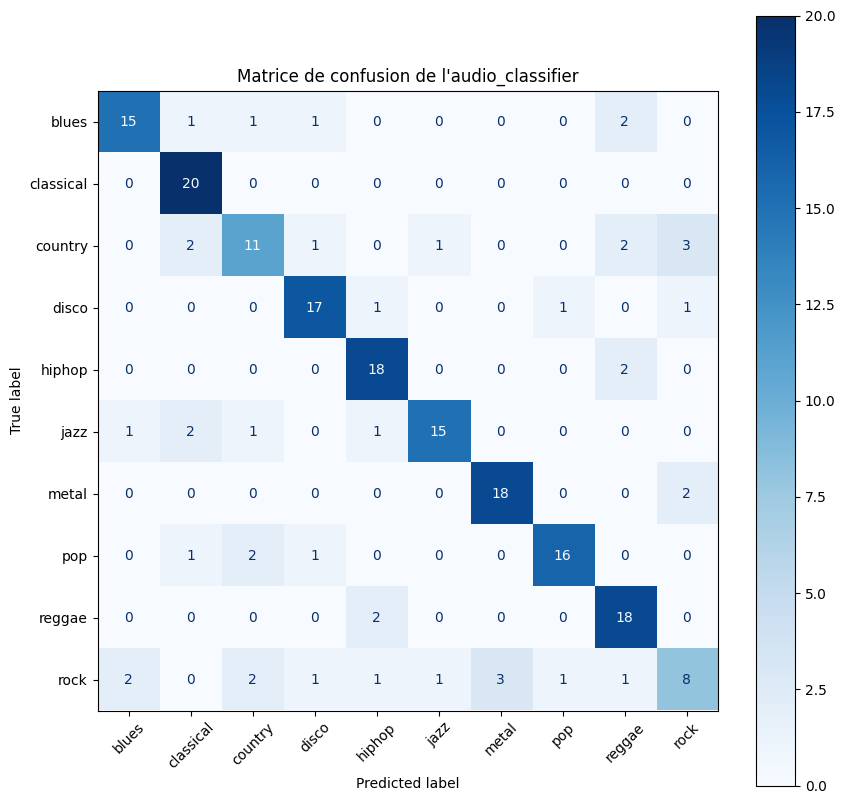

In [24]:
from mlflow.models import infer_signature
from sklearn.metrics import accuracy_score, f1_score

def train(model, train_loader, val_loader, criterion, optimizer, epochs=100, patience=7):

    mlflow.set_tracking_uri(os.getenv("MLFLOW_TRANCKING_URI"))
    mlflow.set_experiment("audio_classifier")
    mlflow.pytorch.autolog(log_models = False)
    #mlflow.pytorch.autolog() 

    full_dt = datetime.datetime.now()
    soft_dt = full_dt.strftime("%Y%m%d_%H%M%S")

    mycallback_acc = ModelCheckpoint(
        filepath = "best_model_gtzan.pth",
        patience = patience,
        min_delta = 0.01,
        mode = "max"
    )

    mycallback_loss = ModelCheckpoint(
        filepath = "best_model_gtzan.pth",
        patience = patience,
        min_delta = 0.001,
        mode = "min"
    )

    with mlflow.start_run(run_name="CNNfeat_audio_classifier_" + soft_dt):

        mlflow.log_params({
            "batch_size": batch_size,
            "learning_rate": lr,
            "weight_decay": 0,
            "epochs": epochs,
            "patience": patience,
            "num_classes": num_classes,
            "device": str(device)
        })

        # Dictionary to store training & validation loss and accuracy over epochs
        d_history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

        min_loss_threshold = 1e-5 # Sécurité pour ne pas descendre à une perte nulle

        for epoch in range(epochs):  # Loop over the number of epochs
            model.train()  # Set model to training mode
            model = model.to(device)
            total_loss, correct = 0, 0  # Initialize total loss and correct predictions

            # Training loop
            # images, features, label_enc
            for inputs,features, labels in train_loader:  #upd
                inputs = inputs.to(device)
                features = features.to(device)   # added
                labels = labels.to(device)
                optimizer.zero_grad()  # Reset gradients before each batch
                outputs = model(inputs,features).squeeze()  # Forward pass  updated
                loss = criterion(outputs, labels)  # Compute loss
                loss.backward()  # Backpropagation (compute gradients)
                optimizer.step()  # Update model parameters

                total_loss += loss.item()  # Accumulate batch loss
                correct += (torch.argmax(outputs,dim=1) == labels).sum().item()  # Count correct predictions

            # Compute average loss and accuracy for training
            train_loss = total_loss / len(train_loader)
            train_acc = correct / len(train_loader.dataset)

            # CONDITION DE SÉCURITÉ : Arrêt si la train_loss approche de zéro
            if train_loss < min_loss_threshold:
                torch.save(model.state_dict(), self.filepath)
                print(f"\n--- Arrêt de sécurité : Train Loss quasi nulle ({train_loss:.6f}) à l'époque {epoch+1} ---")
                break

            # Validation phase (without gradient computation)
            model.eval()  # Set model to evaluation mode
            val_loss, val_correct = 0, 0
            with torch.no_grad():  # No need to compute gradients during validation
                for inputs, features, labels in val_loader: #upd
                    inputs = inputs.to(device)
                    features = features.to(device)   # added
                    labels = labels.to(device)
                    outputs = model(inputs,features).squeeze()  # Forward pass  updated
                    loss = criterion(outputs, labels)  # Compute loss
                    val_loss += loss.item()  # Accumulate validation loss
                    val_correct += (torch.argmax(outputs,dim=1) == labels).sum().item()  # Count correct predictions

            # Compute average loss and accuracy for validation
            val_loss /= len(val_loader)
            val_acc = val_correct / len(val_loader.dataset)

            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("train_acc", train_acc, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)
            mlflow.log_metric("val_acc", val_acc, step=epoch)

            # Store metrics in history dictionary
            d_history['loss'].append(train_loss)
            d_history['val_loss'].append(val_loss)
            d_history['accuracy'].append(train_acc)
            d_history['val_accuracy'].append(val_acc)

            #scheduler.step(val_loss)
            
            if mycallback_acc(model, val_acc):
                print(f"Early stopping à l'époque {epoch}")
                break

            """if mycallback_loss(model, val_loss):
                print(f"Early stopping à l'époque {epoch}")
                break"""


            # Print training progress
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, "
                    f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} -> {val_loss-train_loss:.4f}")

        # PREDICTIONS ET LOGS MLFLOW #####
        # Instanciation du meilleur modèle sauvegaré
        best_model = CNN_AudioSpectralFeatureV2(num_classes = num_classes)
        best_model.load_state_dict(torch.load('best_model_gtzan.pth'))
        # Envoi en GPU pour prédiction du test_loader
        best_model.to(device)
        best_model.eval()
        
        Y_true, Y_pred = [], []
        
        with torch.no_grad():

            for batch_X, batch_feat, batch_Y in test_loader:            # ← MODIF

                batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
                batch_feat = batch_feat.to(device)                      # ← MODIF
                output = best_model(batch_X,batch_feat)                 # ← MODIF

                _, predicted = torch.max(output, 1)
                Y_true.extend(batch_Y.cpu().numpy())
                Y_pred.extend(predicted.cpu().numpy())

        Y_true = np.array(Y_true)
        Y_pred = np.array(Y_pred)
        #####

        # Création des scores #####
        test_acc = accuracy_score(Y_true, Y_pred)
        test_f1 = f1_score(Y_true, Y_pred, average="macro")
        # MLFLOW LOG des scores
        # LOG MLFLOW Divers #####
        mlflow.log_metric("TEST_accuracy", test_acc)
        mlflow.log_metric("TEST_model_f1", test_f1)
        #####
        
        # ── MLFLOW LOG du meilleur modèle ────────────── 
        #input_dummy = torch.randn(1, 2, 128, 256).to(device)
        
        dummy_images   = torch.randn(1, 2, 128, 256).to(device)         # ← MODIF : nommé explicitement
        dummy_features = torch.randn(1, 57).to(device)                  # ← MODIF :
        with torch.no_grad():
            #output_dummy = best_model(input_dummy)
            output_dummy = best_model(dummy_images, dummy_features)      # ← MODIF : 2 args

        # SIgnature pour enregisterer le modèle
        #signature = infer_signature(input_dummy, output_dummy)
        # ← MODIF : signature multi-input via dict
        

        import mlflow.types.schema as mlschema
        from mlflow.models.signature import ModelSignature
        from mlflow.types import Schema, TensorSpec
        import numpy as np_types

        input_schema = Schema([
            TensorSpec(np.dtype("float32"), (-1, 2, 128, 256), name="images"),
            TensorSpec(np.dtype("float32"), (-1, 57),           name="features"),
        ])
        output_schema = Schema([
            TensorSpec(np_types.dtype("float32"), (-1, num_classes)),
        ])
        signature = ModelSignature(inputs=input_schema, outputs=output_schema)


        # MLFLOW Modèle
        mlflow.pytorch.log_model(
            pytorch_model=best_model,
            name="baseline_cnn_feature_audio_classifier",
            registered_model_name="baseline_cnn_feature_audio_classifier",
            signature=signature, # Enregistre le format d'entrée/sortie
            
        )
        #####

        # ── CONFUSION MATRIX ──────────────────────────────────────────────
        class_names = list(mapping_LI.keys())
        fig, ax = plt.subplots(figsize=(10, 10))
        disp = ConfusionMatrixDisplay.from_predictions(
            Y_true, 
            Y_pred, 
            display_labels=class_names, 
            cmap='Blues', 
            xticks_rotation=45,
            ax=ax
        )
        plt.title("Matrice de confusion de l'audio_classifier")
        # LOG MLFLOW CMD
        mlflow.log_figure(fig, "confusion_matrix_audio_classifier_cnn.png")
        #####

        # Création du graphe #####
        # ← MODIF : make_dot avec les 2 inputs
        y   = best_model(dummy_images, dummy_features)
        dot = make_dot(y, params=dict(best_model.named_parameters()))
        img = dot.render("logged_model_graph", format="png")
        
        # MLFLOW LOG du graphe
        mlflow.log_artifact(img)
        #####

        # ── SUMMARY ───────────────────────────────────────────────────────
        # ← MODIF : summary avec input_data multi-tenseurs
        model_summary = summary(best_model, input_data=[dummy_images, dummy_features])

        #model_summary = summary(model_cnn, input_size = (1, 2, 128, 256))
        with open("model_summary.txt", "w") as file:
            file.write(str(model_summary))
        # MLFLOW LOG du summary
        mlflow.log_artifact("model_summary.txt")
        #####

        # MLFLOW LOG LOSS ACC
        mlflowg_historic(d_history)
        #####

        return d_history  # Return training history

d_history = train(model_cnn, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    criterion = criterion, 
    optimizer = optimizer, 
    epochs = 500, patience = 7)


## III.4 *Rewriting of train function*

In [25]:
# ═══════════════════════════════════════════════════════════════════
# IMPORTS — en tête de notebook, une seule fois
# ═══════════════════════════════════════════════════════════════════
import os
import datetime
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
from mlflow.models.signature import ModelSignature, infer_signature
from mlflow.types import Schema, TensorSpec
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
from torchinfo import summary
from torchviz import make_dot


# ═══════════════════════════════════════════════════════════════════
# HELPER : construction de la signature MLflow multi-input
# ═══════════════════════════════════════════════════════════════════
def build_mlflow_signature(num_classes: int) -> ModelSignature:
    input_schema = Schema([
        TensorSpec(np.dtype("float32"), (-1, 2, 128, 256), name="images"),
        TensorSpec(np.dtype("float32"), (-1, 57),           name="features"),
    ])
    output_schema = Schema([
        TensorSpec(np.dtype("float32"), (-1, num_classes)),
    ])
    return ModelSignature(inputs=input_schema, outputs=output_schema)


# ═══════════════════════════════════════════════════════════════════
# HELPER : évaluation sur test_loader → Y_true, Y_pred
# ═══════════════════════════════════════════════════════════════════
def evaluate(model: nn.Module, loader, device: torch.device):
    model.eval()
    Y_true, Y_pred = [], []
    with torch.no_grad():
        for batch_X, batch_feat, batch_Y in loader:
            batch_X    = batch_X.to(device)
            batch_feat = batch_feat.to(device)
            batch_Y    = batch_Y.to(device)
            output     = model(batch_X, batch_feat)
            _, predicted = torch.max(output, 1)
            Y_true.extend(batch_Y.cpu().numpy())
            Y_pred.extend(predicted.cpu().numpy())
    return np.array(Y_true), np.array(Y_pred)


# ═══════════════════════════════════════════════════════════════════
# HELPER : logs MLflow post-training
# ═══════════════════════════════════════════════════════════════════
def log_mlflow_artifacts(
    best_model: nn.Module,
    test_loader,
    device: torch.device,
    num_classes: int,
    mapping: dict,
    d_history: dict,
):
    # --- Évaluation ---
    Y_true, Y_pred = evaluate(best_model, test_loader, device)

    test_acc = accuracy_score(Y_true, Y_pred)
    test_f1  = f1_score(Y_true, Y_pred, average="macro")
    mlflow.log_metric("TEST_accuracy", test_acc)
    mlflow.log_metric("TEST_model_f1", test_f1)
    print(f"TEST  acc={test_acc:.4f}  f1={test_f1:.4f}")

    # --- Dummies pour signature / graphe / summary ---
    dummy_images   = torch.randn(1, 2, 128, 256).to(device)
    dummy_features = torch.randn(1, 57).to(device)
    with torch.no_grad():
        dummy_output = best_model(dummy_images, dummy_features)

    # --- Log modèle ---
    signature = build_mlflow_signature(num_classes)
    mlflow.pytorch.log_model(
        pytorch_model=best_model,
        name="baseline_cnn_feature_audio_classifier",
        registered_model_name="baseline_cnn_feature_audio_classifier",
        signature=signature,
    )

    # --- Confusion matrix ---
    class_names = list(mapping.keys())
    fig, ax = plt.subplots(figsize=(10, 10))
    ConfusionMatrixDisplay.from_predictions(
        Y_true, Y_pred,
        display_labels=class_names,
        cmap="Blues",
        xticks_rotation=45,
        ax=ax,
    )
    plt.title("Matrice de confusion — audio_classifier")
    mlflow.log_figure(fig, "confusion_matrix_audio_classifier_cnn.png")
    plt.close(fig)

    # --- Graphe du modèle ---
    dot = make_dot(dummy_output, params=dict(best_model.named_parameters()))
    img = dot.render("logged_model_graph", format="png")
    mlflow.log_artifact(img)

    # --- Summary ---
    model_summary = summary(best_model, input_data=[dummy_images, dummy_features])
    with open("model_summary.txt", "w") as f:
        f.write(str(model_summary))
    mlflow.log_artifact("model_summary.txt")

    # --- Historique loss/acc ---
    mlflowg_historic(d_history)


# ═══════════════════════════════════════════════════════════════════
# FONCTION PRINCIPALE D'ENTRAÎNEMENT
# ═══════════════════════════════════════════════════════════════════
def train(
    model: nn.Module,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs: int = 100,
    patience: int = 7,
):
    mlflow.set_tracking_uri(os.getenv("MLFLOW_TRANCKING_URI"))
    mlflow.set_experiment("audio_classifier")
    mlflow.pytorch.autolog(log_models=False)

    run_name = "CNNfeat_audio_classifier_" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    mycallback_acc = ModelCheckpoint(
        filepath="best_model_gtzan.pth",
        patience=patience,
        min_delta=0.01,
        mode="max",
    )

    with mlflow.start_run(run_name=run_name):

        mlflow.log_params({
            "batch_size":   batch_size,
            "learning_rate": lr,
            "weight_decay":  0,
            "epochs":        epochs,
            "patience":      patience,
            "num_classes":   num_classes,
            "device":        str(device),
        })

        d_history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
        min_loss_threshold = 1e-5
        model = model.to(device)

        for epoch in range(epochs):

            # ── Train ────────────────────────────────────────────────────
            model.train()
            total_loss, correct = 0, 0

            for inputs, features, labels in train_loader:
                inputs   = inputs.to(device)
                features = features.to(device)
                labels   = labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs, features).squeeze()
                loss    = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                correct    += (torch.argmax(outputs, dim=1) == labels).sum().item()

            train_loss = total_loss / len(train_loader)
            train_acc  = correct   / len(train_loader.dataset)

            if train_loss < min_loss_threshold:
                torch.save(model.state_dict(), "best_model_gtzan.pth")
                print(f"Arrêt sécurité : train_loss={train_loss:.6f} epoch {epoch+1}")
                break

            # ── Validation ───────────────────────────────────────────────
            model.eval()
            val_loss, val_correct = 0, 0
            with torch.no_grad():
                for inputs, features, labels in val_loader:
                    inputs   = inputs.to(device)
                    features = features.to(device)
                    labels   = labels.to(device)
                    outputs  = model(inputs, features).squeeze()
                    val_loss    += criterion(outputs, labels).item()
                    val_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()

            val_loss /= len(val_loader)
            val_acc   = val_correct / len(val_loader.dataset)

            # ── Logs ─────────────────────────────────────────────────────
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("train_acc",  train_acc,  step=epoch)
            mlflow.log_metric("val_loss",   val_loss,   step=epoch)
            mlflow.log_metric("val_acc",    val_acc,    step=epoch)

            d_history["loss"].append(train_loss)
            d_history["val_loss"].append(val_loss)
            d_history["accuracy"].append(train_acc)
            d_history["val_accuracy"].append(val_acc)

            print(
                f"Epoch [{epoch+1:03d}/{epochs}]  "
                f"loss={train_loss:.4f}  acc={train_acc:.4f}  "
                f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
                f"gap={val_loss-train_loss:+.4f}"
            )

            if mycallback_acc(model, val_acc):
                print(f"Early stopping à l'époque {epoch+1}")
                break

        # ── Post-training : chargement best model + logs MLflow ──────────
        best_model = CNN_AudioSpectralFeatureV2(num_classes=num_classes)
        best_model.load_state_dict(torch.load("best_model_gtzan.pth", weights_only=True))
        best_model.to(device)

        log_mlflow_artifacts(
            best_model=best_model,
            test_loader=test_loader,
            device=device,
            num_classes=num_classes,
            mapping=mapping_LI,
            d_history=d_history,
        )

        return d_history


# ═══════════════════════════════════════════════════════════════════
# APPEL
# ═══════════════════════════════════════════════════════════════════
d_history = train(
    model_cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=500,
    patience=7,
)


Epoch [001/500]  loss=0.0401  acc=0.9616  val_loss=0.7359  val_acc=0.7900  gap=+0.6958
First save
Epoch [002/500]  loss=0.0393  acc=0.9599  val_loss=0.7382  val_acc=0.7800  gap=+0.6989
Epoch [003/500]  loss=0.0383  acc=0.9616  val_loss=0.7098  val_acc=0.7800  gap=+0.6715
Epoch [004/500]  loss=0.0388  acc=0.9616  val_loss=0.7675  val_acc=0.7650  gap=+0.7287
Epoch [005/500]  loss=0.0346  acc=0.9616  val_loss=0.7382  val_acc=0.7800  gap=+0.7037
Epoch [006/500]  loss=0.0349  acc=0.9616  val_loss=0.7052  val_acc=0.7950  gap=+0.6703
Save
Epoch [007/500]  loss=0.0319  acc=0.9616  val_loss=0.7234  val_acc=0.8050  gap=+0.6916
Save
Epoch [008/500]  loss=0.0294  acc=0.9616  val_loss=0.7238  val_acc=0.7800  gap=+0.6943
Epoch [009/500]  loss=0.0321  acc=0.9599  val_loss=0.6785  val_acc=0.7900  gap=+0.6464
Epoch [010/500]  loss=0.0240  acc=0.9616  val_loss=0.7332  val_acc=0.7800  gap=+0.7092
Epoch [011/500]  loss=0.0263  acc=0.9616  val_loss=0.6767  val_acc=0.8050  gap=+0.6504
Save
Epoch [012/500]  

2026/06/14 20:30:42 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


TEST  acc=0.7950  f1=0.7959


2026/06/14 20:30:47 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.23.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.23.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
Registered model 'baseline_cnn_feature_audio_classifier' already exists. Creating a new version of this model...
Created version '3' of model 'baseline_cnn_feature_audio_classifier'.


NameError: name 'mlflowg_historic' is not defined

# **IV. Charts of Loss & Accuracy across Epochs**

In [27]:
import matplotlib.pyplot as plt

    # --- Graphique 1 : Training and Val Loss ---
def mlflowg_historic(d_history:dict):
    # 1. Création de la figure (Taille 10x4 recommandée pour la lisibilité) [2]
    fig_loss, ax1 = plt.subplots(figsize=(10, 4))

    # 2. Ajout des courbes
    ax1.plot(d_history["loss"], label="Training loss", color="blue", linestyle="-")
    ax1.plot(d_history["val_loss"], label="Validation loss", color="green", linestyle="-")

    # 3. Configuration (Titres et labels) [3]
    ax1.set_title('Training and Val Loss across epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Cross Entropy')
    ax1.legend()

    # 4. ENVOI À MLFLOW
    # Cela enregistre l'image PNG sur le serveur dans les artefacts du run
    mlflow.log_figure(fig_loss, "history_loss.png")

    # --- Graphique 2 : Training and Val Accuracy ---

    # 1. Création de la figure
    fig_acc, ax2 = plt.subplots(figsize=(10, 4))

    # 2. Ajout des courbes
    ax2.plot(d_history["accuracy"], label="Training Acc", color="red", linestyle="-")
    ax2.plot(d_history["val_accuracy"], label="Validation Acc", color="purple", linestyle="-")

    # 3. Configuration
    ax2.set_title('Training and Val Accuracy across epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    # 4. ENVOI À MLFLOW
    mlflow.log_figure(fig_acc, "history_acc.png")

    # Optionnel : Fermer les figures pour libérer la mémoire vive
    plt.close(fig_loss)
    plt.close(fig_acc)